# HR CAPSTONE PROJECT


#### TEAM DATANAUT (Group 14)


In this project, I am developing a predictive system that identifies employees who are likely to resign based on demographic information, job characteristics, compensation, and workplace factors.

In [711]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [712]:
HR = pd.read_csv(r"C:\Users\USER\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")

HR.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


# Data Information

In [714]:
HR.shape

(1470, 35)

In [715]:
HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [716]:
HR.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [717]:
HR.duplicated().sum()

0

In [718]:
#check value count

attr_count = HR["Attrition"].value_counts()

attr_count

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [719]:
#checking the percentage

attr_pct = HR["Attrition"].value_counts(normalize=True) * 100

attr_pct

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

# Analysis of OverTime

In [721]:
overtime_analysis = pd.crosstab(HR["OverTime"], HR["Attrition"], normalize='index') * 100

print("Percentage of Attrition by OverTime Status:")
overtime_analysis

Percentage of Attrition by OverTime Status:


Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


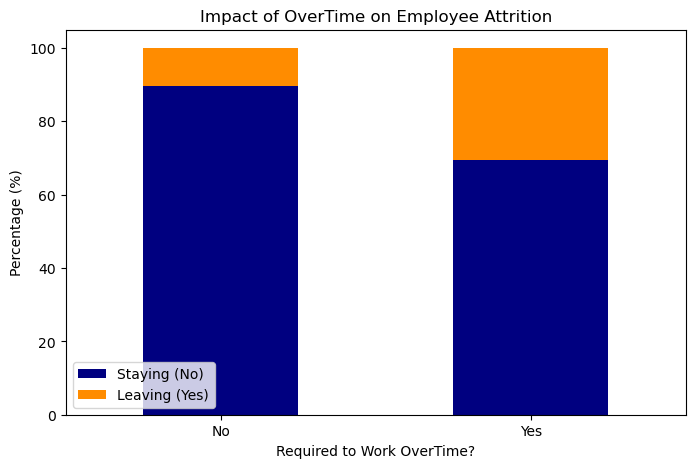

In [722]:
# Plot a stacked bar chart to visualize the impact

overtime_analysis.plot(kind="bar", stacked = True, color=["navy", "darkorange"], figsize=(8, 5))

plt.title("Impact of OverTime on Employee Attrition")
plt.ylabel("Percentage (%)")
plt.xlabel("Required to Work OverTime?")
plt.xticks(rotation=0)

plt.legend(["Staying (No)", "Leaving (Yes)"], loc="lower left")

plt.show()

## Insight:
This chart simply tells us that OverTime is a giant here. Working late makes workers three times more likely to walk out the company.

# Analysis of MonthlyIncome
We want to separate the workers by how much money they earn

In [725]:
# Calculate summary statistics for Monthly Income based on Attrition

income_summary = HR.groupby("Attrition")["MonthlyIncome"].describe()

print("Monthly Income Statistics by Attrition Status:")

income_summary

Monthly Income Statistics by Attrition Status:


,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


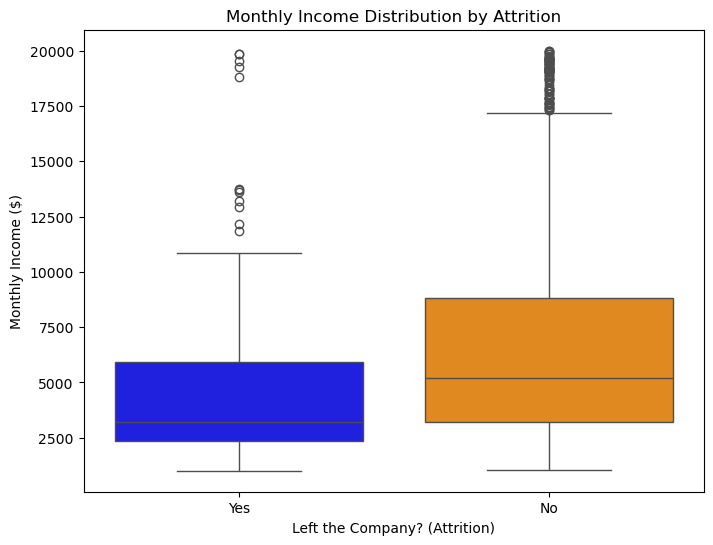

In [726]:
# Plot a boxplot to visualize the income distribution

plt.figure(figsize=(8, 6))
sns.boxplot(data= HR, x="Attrition", y="MonthlyIncome", palette=["blue", "darkorange"])

plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Left the Company? (Attrition)")
plt.ylabel("Monthly Income ($)")

plt.show()

## Insight:
This visualization tells a clear story: employees earning lower salaries are much more likely to pack up their bags and leave, while the high-earning outliers stay perfectly comfortable where they are.

My calculations below also prove that Income is a massive shield against Attrition.

# Income Outliers

In [729]:
# Calculate the outlier boundary for employees who left

income_yes = HR[HR["Attrition"] == "Yes"]["MonthlyIncome"]

In [730]:
Q1 = income_yes.quantile(0.25)

Q1

2373.0

In [731]:
Q2 = income_yes.quantile(0.50)

Q2

3202.0

In [732]:
Q3 = income_yes.quantile(0.75)

Q3

5916.0

In [733]:
IQR = Q3 - Q1

IQR

3543.0

In [734]:
upper_boundary = Q3 + (1.5 * IQR)

upper_boundary

11230.5

In [735]:
# Filter the dataset to see these high earners

income_outliers = HR[(HR["Attrition"] == "Yes") & (HR["MonthlyIncome"] > upper_boundary)]

print(f"Income boundary for outliers: ${upper_boundary:.2f}")
print(f"Number of high-income outliers who left: {len(income_outliers)}")

Income boundary for outliers: $11230.50
Number of high-income outliers who left: 12


In [736]:
# Display key details about these individuals

income_outliers[["Age", "JobRole", "MonthlyIncome", "OverTime", "YearsAtCompany"]]

,Age,JobRole,MonthlyIncome,OverTime,YearsAtCompany
45,41,Research Director,19545,No,22
271,47,Manager,11849,Yes,10
435,33,Manager,13610,Yes,7
568,55,Manager,19859,Yes,5
595,58,Research Director,19246,Yes,31
706,40,Sales Executive,13194,Yes,1
749,52,Manager,19845,No,32
813,39,Healthcare Representative,12169,No,18
838,42,Sales Executive,13758,Yes,21
913,45,Manager,18824,Yes,24


# Job Satisfaction vs Attrition

In [738]:
# Job Satisfaction ratings with Attrition

satisfaction_analysis = pd.crosstab(HR["JobSatisfaction"], HR["Attrition"], normalize="index") * 100

print("Percentage of Attrition by Job Satisfaction Level:")

satisfaction_analysis

Percentage of Attrition by Job Satisfaction Level:


Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


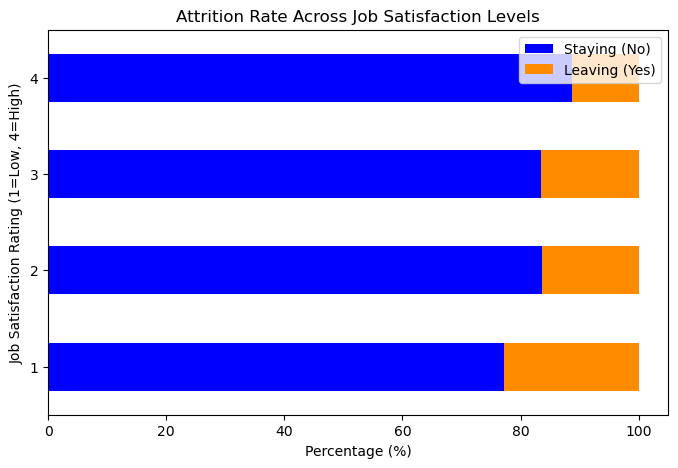

In [739]:
# Stacked horizontal bar chart to visualize the trend

satisfaction_analysis.plot(kind = "barh", stacked = True, color = ["blue", "darkorange"], figsize = (8, 5))

plt.title("Attrition Rate Across Job Satisfaction Levels")
plt.xlabel("Percentage (%)")
plt.ylabel("Job Satisfaction Rating (1=Low, 4=High)")
plt.legend(["Staying (No)", "Leaving (Yes)"], loc = "upper right")

plt.show()

## Insight:
This chat proves a simple rule. When employees are happy with their daily pay tasks, they stay in the factory much longer.

In [741]:
HR.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [742]:
HR.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [743]:
# pick out the numerical columns from the data

numerical_cols = HR.select_dtypes(include =["int64", "float64"]).columns.tolist()

numerical_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [744]:
# pick out the categorical columns from the data

categorical_cols = HR.select_dtypes(include = ["object"]).columns.tolist()

categorical_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

# Data Preprocessing

In [746]:
HR.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## Feature Engineering

In [748]:
# Define a function for Promotion Stagnation Index

def get_stagnation_index(row):
    # Add 1 to YearsAtCompany to avoid dividing by zero if a worker just started
    return row["YearsSinceLastPromotion"] / (row["YearsAtCompany"] + 1)

In [749]:
HR["PromotionStagnationIndex"] = HR.apply(get_stagnation_index, axis=1)

In [750]:
# Define a function for Income Per Year at Company

def get_income_per_year(row):
    return row["MonthlyIncome"] / (row["YearsAtCompany"] + 1)

In [751]:
HR["IncomePerYearAtCompany"] = HR.apply(get_income_per_year, axis=1)

In [752]:
# Define a function for Role Tenure Ratio

def get_role_tenure_ratio(row):
    return row["YearsInCurrentRole"] / (row["YearsAtCompany"] + 1)

In [753]:
HR["RoleTenureRatio"] = HR.apply(get_role_tenure_ratio, axis=1)

In [754]:
HR.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5,0.000000,856.142857,0.571429
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7,0.090909,466.363636,0.636364
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0,0.000000,2090.000000,0.000000


## Feature Engineering of the categorical columns

In [756]:
cat_cols = ["BusinessTravel", "Department", "EducationField", "MaritalStatus", "JobRole", "Gender", "OverTime"]

# 2. Engineer the new columns using pd.get_dummies

HR = pd.get_dummies(HR, columns=cat_cols, drop_first=True, dtype=int)

In [757]:
HR.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Gender_Male,OverTime_Yes
0,41,Yes,1102,1,2,1,1,2,94,3,2,4,5993,19479,8,Y,11,3,1,80,0,8,0,1,6,4,0,5,0.000000,856.142857,0.571429,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
1,49,No,279,8,1,1,2,3,61,2,2,2,5130,24907,1,Y,23,4,4,80,1,10,3,3,10,7,1,7,0.090909,466.363636,0.636364,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,37,Yes,1373,2,2,1,4,4,92,2,1,3,2090,2396,6,Y,15,3,2,80,0,7,3,3,0,0,0,0,0.000000,2090.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1
3,33,No,1392,3,4,1,5,4,56,3,1,3,2909,23159,1,Y,11,3,3,80,0,8,3,3,8,7,3,0,0.333333,323.222222,0.777778,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
4,27,No,591,2,1,1,7,1,40,3,1,2,3468,16632,9,Y,12,3,4,80,1,6,3,3,2,2,2,2,0.666667,1156.000000,0.666667,0,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0


# Drop redundant columns

In [759]:
X = HR.drop(columns = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber", "DailyRate", "HourlyRate", "MonthlyRate", "YearsSinceLastPromotion", "YearsInCurrentRole", "Attrition"])


In [760]:
X.head()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Gender_Male,OverTime_Yes
0,41,1,2,2,3,2,4,5993,8,11,3,1,0,8,0,1,6,5,0.000000,856.142857,0.571429,0,1,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1
1,49,8,1,3,2,2,2,5130,1,23,4,4,1,10,3,3,10,7,0.090909,466.363636,0.636364,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,37,2,2,4,2,1,3,2090,6,15,3,2,0,7,3,3,0,0,0.000000,2090.000000,0.000000,0,1,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,1,1
3,33,3,4,4,3,1,3,2909,1,11,3,3,0,8,3,3,8,0,0.333333,323.222222,0.777778,1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
4,27,2,1,1,3,1,2,3468,9,12,3,4,1,6,3,3,2,2,0.666667,1156.000000,0.666667,0,1,1,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0


In [761]:
X.sample(5)

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsWithCurrManager,PromotionStagnationIndex,IncomePerYearAtCompany,RoleTenureRatio,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,MaritalStatus_Married,MaritalStatus_Single,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Gender_Male,OverTime_Yes
1173,36,5,4,2,3,3,1,8008,4,12,3,3,2,9,6,3,3,2,0.0,2002.000000,0.500000,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
344,35,5,4,3,3,3,2,8095,0,13,3,4,0,17,5,3,16,13,0.0,476.176471,0.352941,0,1,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0
1021,25,9,2,1,2,1,1,4400,3,12,3,1,0,6,2,3,3,2,0.5,1100.000000,0.500000,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0
23,21,15,2,3,3,1,4,1232,1,14,3,4,0,0,6,3,0,0,0.0,1232.000000,0.000000,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0
970,27,11,3,3,4,1,4,2534,8,14,3,2,1,5,4,3,1,0,0.0,1267.000000,0.000000,0,1,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0


## Convert Attrition text to numbers

In [763]:
HR["Attrition"] = HR["Attrition"].map({"Yes": 1, "No": 0})

In [764]:
y = HR["Attrition"]

y.head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64

# Feature Correlation

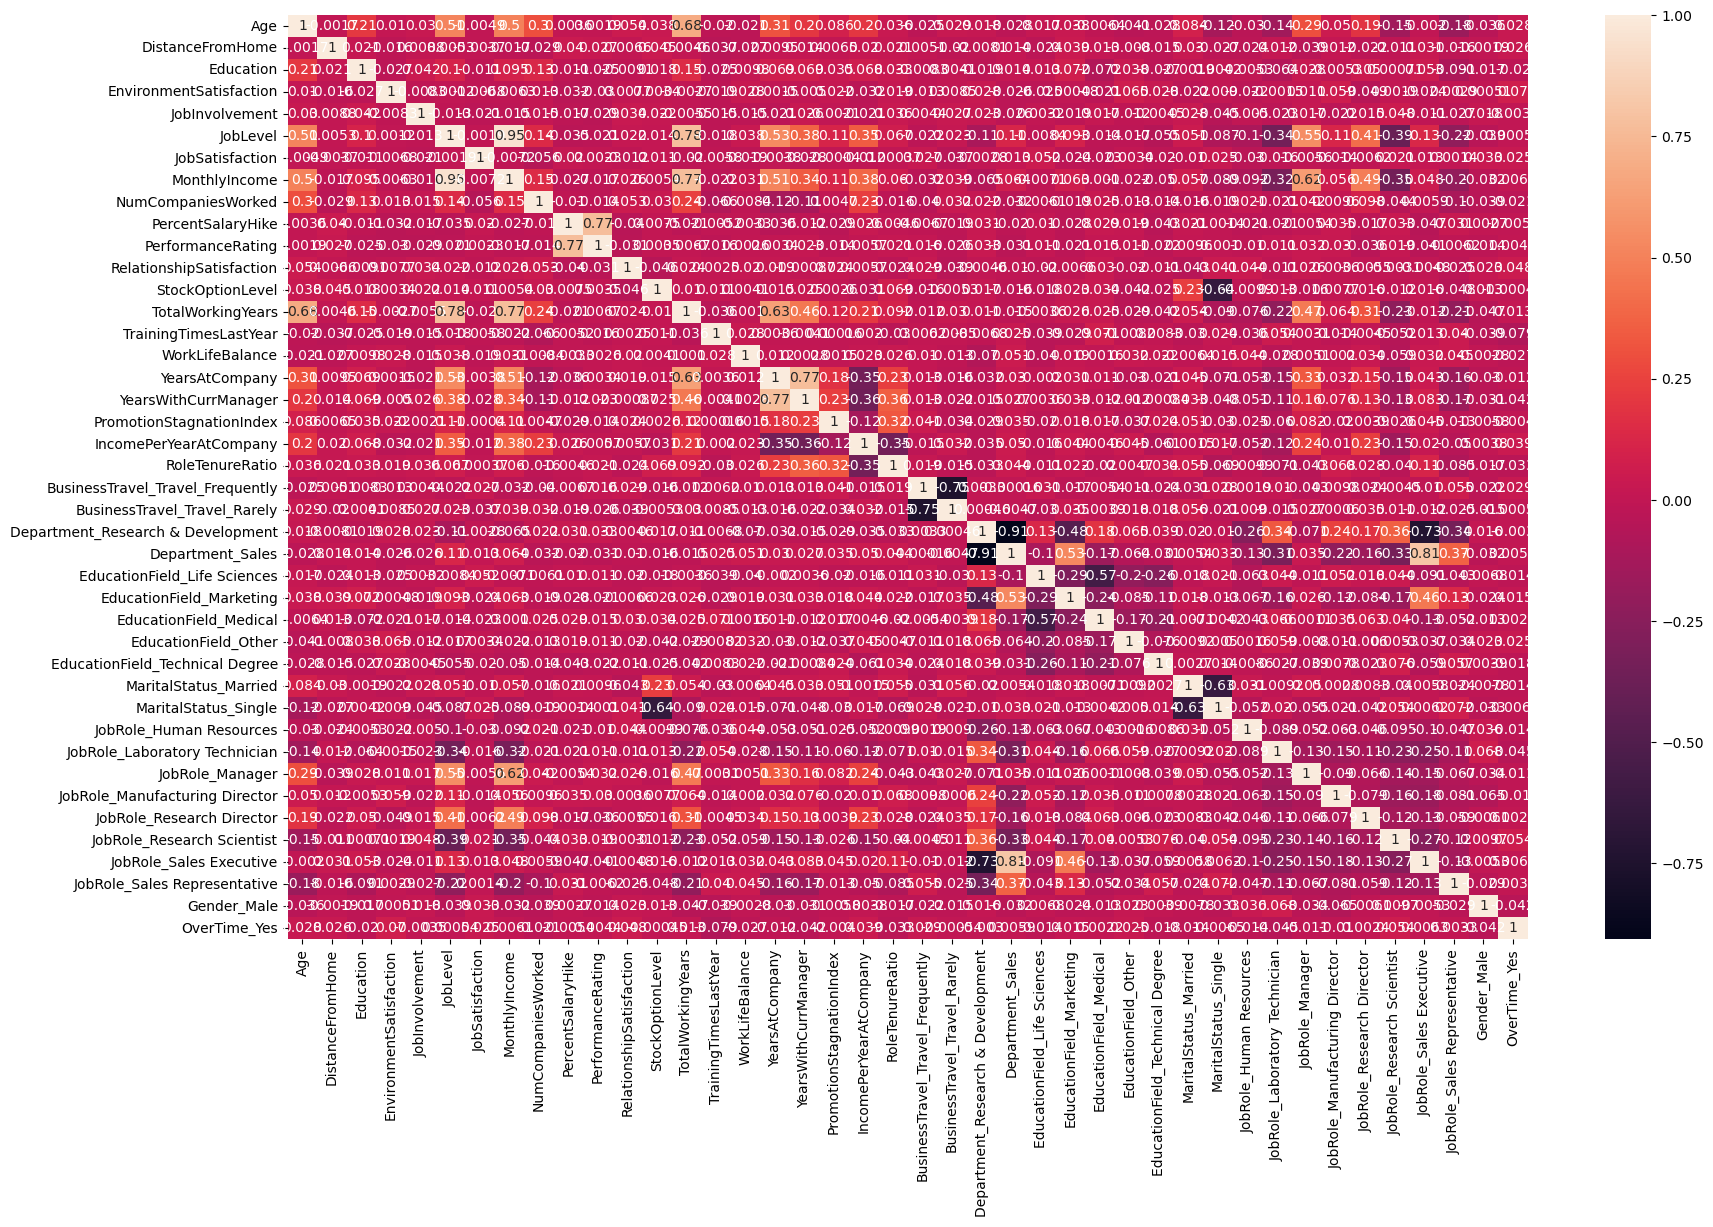

In [766]:
# Using Heatmap

plt.figure(figsize=(20, 12))
sns.heatmap(X.corr(), annot=True)

plt.show()

# Feature Scaling

In [768]:
# Import StandardScaler

In [769]:
# Create an instance first

scaler = StandardScaler()

scaledX = scaler.fit_transform(X)

In [770]:
scaledX

array([[ 0.4463504 , -1.01090934, -0.89168825, ..., -0.24462499,
        -1.22474487,  1.59174553],
       [ 1.32236521, -0.14714972, -1.86842575, ..., -0.24462499,
         0.81649658, -0.62824112],
       [ 0.008343  , -0.88751511, -0.89168825, ..., -0.24462499,
         0.81649658,  1.59174553],
       ...,
       [-1.08667552, -0.64072665,  0.08504925, ..., -0.24462499,
         0.81649658,  1.59174553],
       [ 1.32236521, -0.88751511,  0.08504925, ..., -0.24462499,
         0.81649658, -0.62824112],
       [-0.32016256, -0.14714972,  0.08504925, ..., -0.24462499,
         0.81649658, -0.62824112]])

In [771]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

# Train-test split

In [773]:
# Importing library for a train-test split

In [774]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size=0.2, random_state=35)

# Training

In [776]:
# Importing LogisticRegression

In [777]:
#create an instance fit of the training data

log = LogisticRegression()

log.fit(X_train, y_train)

LogisticRegression()

In [778]:
log_preds = log.predict(X_test)

log_preds

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0], dtype=int64)

# Test model
### Using Accuracy_score

In [780]:
# Let's test how accurate our model is doing

accuracy_score(y_test, log_preds)

0.8843537414965986

# Classification Report

In [782]:
print(classification_report(y_test, log_preds))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       256
           1       0.58      0.39      0.47        38

    accuracy                           0.88       294
   macro avg       0.75      0.68      0.70       294
weighted avg       0.87      0.88      0.87       294



# Confusion Matrix

In [784]:
cm = confusion_matrix(y_test, log_preds)

cm

array([[245,  11],
       [ 23,  15]], dtype=int64)

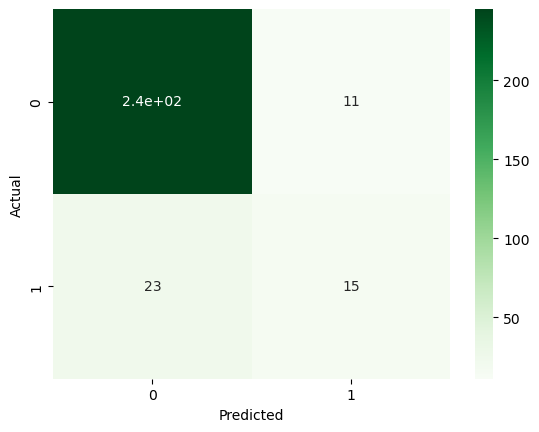

In [785]:
#visualize

sns.heatmap(cm, annot=True, cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#### True Negative - 245:
- The number of employees who stay the model predicted correctly.
#### False Positive - 11:
- The number of employees who stay the model predicted they leave.
#### True Positive - 15:
- The number of employees who leave the model rightly predicted
#### False Negative - 23:
- The number of employees who leave the model predicted they stay

# Precision

Precision = TP/(TP + FP)

Of all transactions predicted as fraud, how many are actually fraud?

In [789]:
15/(15+11)

0.5769230769230769

# Recall

Recall = TP/(TP + FN)

Of all fraudulent transactions, how many did the model catch?

In [792]:
15/(15+23)

0.39473684210526316

# F1-Score Metrics
## RandomRorest Model

In [794]:
# Import RandomForest Classifier

In [795]:
forest = RandomForestClassifier(random_state=30)

forest.fit(X_train, y_train)

RandomForestClassifier(random_state=30)

In [796]:
forest_preds = forest.predict(X_test)

forest_preds

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [797]:
print(classification_report(y_test, forest_preds))

              precision    recall  f1-score   support

           0       0.89      0.99      0.94       256
           1       0.71      0.13      0.22        38

    accuracy                           0.88       294
   macro avg       0.80      0.56      0.58       294
weighted avg       0.86      0.88      0.84       294

